In [2]:
import os
import importlib.util
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from model import NonLinearFCEncode as ThisEncoder


def load_config(config_path):
    spec = importlib.util.spec_from_file_location("config", config_path)
    config = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(config)
    return config


def load_encoder_checkpoint(
    config_path,
    checkpoint_path,
    device=None,
    strict=False
):
    """
    Load a trained NonLinearFCEncode checkpoint.

    Assumes the model constructor is:
        ThisEncoder(in_features, hid_features, out_features)

    This follows your current evaluation script.
    """
    config = load_config(config_path)

    if device is None:
        device = config.DEVICE

    model = ThisEncoder(
        in_features=config.IN_FEATURES,
        hid_features=config.HID_FEATURES,
        out_features=config.OUT_FEATURES
    ).to(device)

    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state, strict=strict)
    model.eval()

    return model, config, device

In [3]:
def probe_height_continuum(
    model,
    base_x,
    height_idx,
    height_values,
    device,
    duration_idx=None,
    fixed_duration=None,
    save_csv_path=None,
    save_fig_path=None,
):
    """
    Probe whether the L1-trained encoder maps the /i/-/e/ height continuum
    approximately linearly or nonlinearly.

    Parameters
    ----------
    model:
        Trained encoder model. Assumes model(x) returns hidden representation.

    base_x:
        A representative input vector, shape [input_dim].
        This is used as the template. Only height_idx, and optionally duration_idx,
        will be modified.

    height_idx:
        Index of the vowel-height dimension in the flattened input vector.

    height_values:
        List or numpy array of artificial height values from /i/ to /e/.

    device:
        torch device.

    duration_idx:
        Optional. Index of the duration dimension.

    fixed_duration:
        Optional. If given, all probes use this same duration value.

    save_csv_path:
        Optional. Path to save the diagnostic dataframe.

    save_fig_path:
        Optional. Path to save the plot.

    Returns
    -------
    df:
        DataFrame containing input height, latent projection, local expansion,
        off-axis distance, and latent coordinates.

    z:
        Latent representations as numpy array, shape [n_probes, latent_dim].

    probes:
        Artificial input probes as numpy array, shape [n_probes, input_dim].
    """

    model.eval()

    if torch.is_tensor(base_x):
        base_x = base_x.detach().cpu().numpy()

    base_x = np.asarray(base_x).astype(np.float32).reshape(-1)
    height_values = np.asarray(height_values).astype(np.float32)

    probes = []

    for h in height_values:
        x = base_x.copy()
        x[height_idx] = h

        if duration_idx is not None and fixed_duration is not None:
            x[duration_idx] = fixed_duration

        probes.append(x)

    probes = np.stack(probes, axis=0)

    with torch.no_grad():
        x_tensor = torch.tensor(probes, dtype=torch.float32, device=device)
        z_tensor = model(x_tensor)

        if z_tensor.dim() == 1:
            z_tensor = z_tensor.unsqueeze(1)

        z = z_tensor.detach().cpu().numpy()

    # -----------------------------
    # Input-space normalized position
    # -----------------------------
    input_t = (height_values - height_values[0]) / (
        height_values[-1] - height_values[0] + 1e-12
    )

    input_steps = np.abs(np.diff(height_values))

    # -----------------------------
    # Latent-space analysis
    # -----------------------------
    z0 = z[0]
    z1 = z[-1]
    axis = z1 - z0
    axis_norm = np.linalg.norm(axis) + 1e-12
    axis_unit = axis / axis_norm

    # Projection of each latent point onto the /i/-/e/ latent axis
    latent_proj = (z - z0) @ axis_unit

    # Normalized latent position along the /i/-/e/ axis
    latent_t = latent_proj / axis_norm

    # Reconstructed point on the straight latent /i/-/e/ line
    z_on_axis = z0 + np.outer(latent_proj, axis_unit)

    # Distance away from the straight /i/-/e/ latent line
    off_axis_dist = np.linalg.norm(z - z_on_axis, axis=1)

    # Consecutive latent distances
    latent_steps = np.linalg.norm(np.diff(z, axis=0), axis=1)

    # Local expansion ratio: how much each input height step expands/compresses in latent space
    local_expansion = latent_steps / (input_steps + 1e-12)

    # Pad step-based quantities so dataframe has same length as probes
    input_step_to_next = np.concatenate([input_steps, [np.nan]])
    latent_step_to_next = np.concatenate([latent_steps, [np.nan]])
    local_expansion_to_next = np.concatenate([local_expansion, [np.nan]])

    df = pd.DataFrame({
        "probe_id": np.arange(len(height_values)),
        "height_value": height_values,
        "input_t": input_t,
        "latent_projection": latent_proj,
        "latent_t": latent_t,
        "off_axis_dist": off_axis_dist,
        "input_step_to_next": input_step_to_next,
        "latent_step_to_next": latent_step_to_next,
        "local_expansion_to_next": local_expansion_to_next,
    })

    # Add latent dimensions as columns
    for d in range(z.shape[1]):
        df[f"z{d}"] = z[:, d]

    if save_csv_path is not None:
        df.to_csv(save_csv_path, index=False)
        print(f"Saved probe dataframe to: {save_csv_path}")

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(df["input_t"], df["latent_t"], marker="o")
    ax.plot([0, 1], [0, 1], linestyle="--")

    ax.set_xlabel("Input position along /i/-/e/ height continuum")
    ax.set_ylabel("Latent projection along /i/-/e/ axis")
    ax.set_title("Input height continuum vs. latent projection")

    if save_fig_path is not None:
        fig.savefig(save_fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {save_fig_path}")

    plt.show()

    return df, z, probes

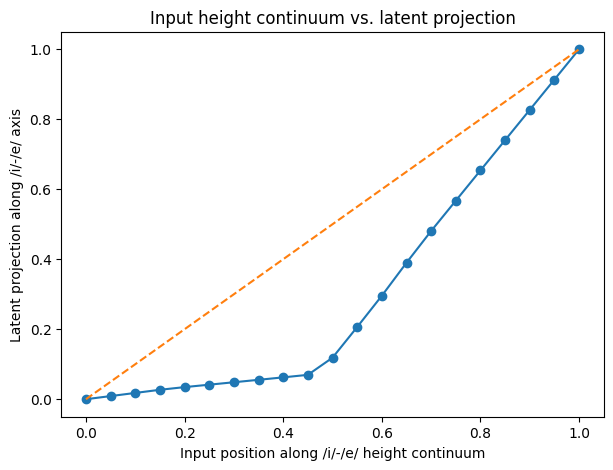

In [25]:
config_path = "./configs/T_0430_RCRC_EQL_EWCp4_1e4_HID4.py"

checkpoint_path = (
    "./"
    "weights/0430_RCRC_EQL_EWCp4_1e4_HID4/1/checkpoint_epoch_300.pt"
)

model, config, device = load_encoder_checkpoint(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    strict=False
)

# Example: create a base vector.
# Best option: use the mean of real L1 inputs or one representative token.
base_x = np.zeros(config.IN_FEATURES, dtype=np.float32)

# Replace these with your actual flattened input indices
height_idx = 5
duration_idx = 6

# Artificial height values from /i/ to /e/
height_values = np.linspace(-1.0, 1.0, 21)

df, z, probes = probe_height_continuum(
    model=model,
    base_x=base_x,
    height_idx=height_idx,
    height_values=height_values,
    duration_idx=duration_idx,
    fixed_duration=0.0,
    device=device,
    save_csv_path=None,
    save_fig_path=None
)

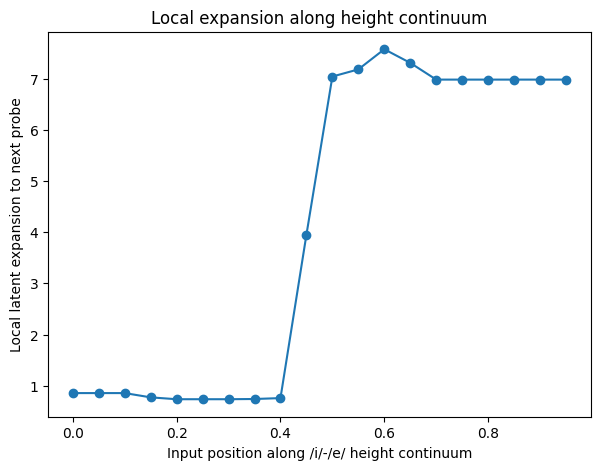

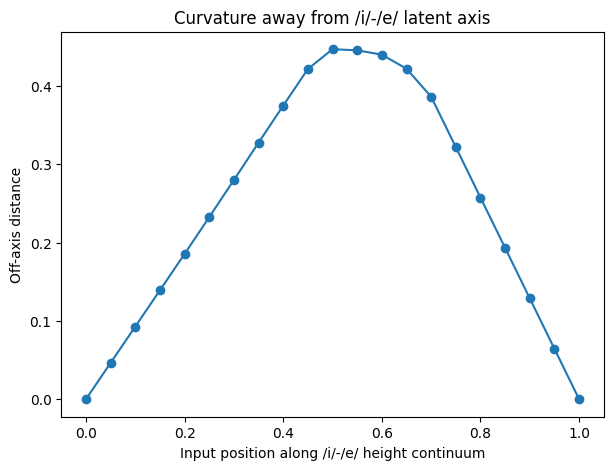

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(df["input_t"], df["local_expansion_to_next"], marker="o")
plt.xlabel("Input position along /i/-/e/ height continuum")
plt.ylabel("Local latent expansion to next probe")
plt.title("Local expansion along height continuum")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(df["input_t"], df["off_axis_dist"], marker="o")
plt.xlabel("Input position along /i/-/e/ height continuum")
plt.ylabel("Off-axis distance")
plt.title("Curvature away from /i/-/e/ latent axis")
plt.show()